# Modèle Bayésien Hiérarchique de la Fréquence des Sinistres d'Assurance par Région

## Synthèse

Un assureur IARD a besoin de la fréquence de sinistres auto attendue pour chaque territoire de tarification, mais certains territoires ont une exposition faible, si bien que leurs taux bruts réagissent de façon excessive à une poignée de sinistres. À l'aide de **PROC MCMC**, nous ajustons une régression de Poisson hiérarchique avec un décalage d'exposition, une covariable de franchise au niveau de la police, et des ordonnées aléatoires par région tirées d'une hyperdistribution commune. L'ajustement retrouve une moyenne a posteriori de la fréquence-log de référence de **0,43** (`beta0`), une pente de franchise négative (`beta_ded` moyenne a posteriori **-0,13**, intervalle de crédibilité à 95% d'environ **[-0,32, 0,10]**), et un écart-type inter-région d'environ **0,72** (déduit de la moyenne a posteriori de `tau2`). Le regroupement partiel ramène les estimations les plus bruitées des petites régions vers le centre du portefeuille : la région 5, peu exposée et à taux élevé (fréquence brute 3,41), se stabilise à une relativité a posteriori de **1,43**, tandis que la région 4, peu exposée et à faible taux (fréquence brute 0,45), se stabilise à **0,49** — chacune avec de larges bandes de crédibilité qui signalent leurs données limitées. La distribution a posteriori complète transforme la relativité de chaque région en un intervalle de crédibilité utilisable pour les décisions de tarification et de capital.

## Sources de Données

Toutes les données sont générées de façon synthétique dans le notebook (aucun fichier externe). Une seule étape DATA simule un portefeuille de polices sur une année pour 6 régions.

| Jeu de données | Lignes | Variable | Description |
|---------|------|----------|-------------|
| `claims` | 96 années-police | `region` | Identifiant de région 1-6 (territoire de tarification) |
| | | `exposure` | Exposition acquise en années-police (0,3-1,0) |
| | | `deductible` | Franchise de police standardisée (centrée) |
| | | `region_eff` | Véritable effet latent de fréquence-log par région (pour référence) |
| | | `nclaims` | Nombre de sinistres observés ~ Poisson(exposure x exp(eta)) |

Le véritable processus générateur des données est `log(rate) = beta0 + beta_ded * deductible + u_region`, avec des ordonnées de région `u_region` allant de **-0,45 à +0,40** et un décalage `exposure`, de sorte que la distribution a posteriori retrouvée puisse être comparée à la vérité simulée. Les tailles des régions sont volontairement inégales (24, 20, 16, 14, 12, 10 années-police) afin que les petits territoires présentent les taux bruts bruyants que le regroupement partiel est conçu pour stabiliser.

> **Remarque sur la taille de l'échantillon.** Cet environnement fonctionne sans licence, ce qui plafonne chaque jeu de données à 100 observations. Le portefeuille est donc dimensionné à 96 années-police réparties sur 6 régions — suffisamment petit pour respecter le plafond tout en donnant à chaque région sa propre ordonnée aléatoire. Les résumés a posteriori imprimés par PROC MCMC utilisent la chaîne complète de 6 000 tirages sauvegardés ; toute étape *en aval* qui relit le jeu de données `OUTPOST=` (les intervalles de crédibilité par région et les graphiques de trace/densité ci-dessous) ne voit que les 100 premiers tirages sauvegardés, à nouveau à cause du plafond. Ces résumés en aval sont une tranche honnête et précoce de la chaîne, non la distribution a posteriori complète, et sont étiquetés comme tels.

# Fréquence de Sinistres Bayésienne Hiérarchique par Région

Un assureur IARD a besoin de la **fréquence de sinistres attendue par région** pour définir les relativités des territoires de tarification. Le défi : les petites régions/régions rurales ont peu d'exposition, si bien que leurs taux de sinistres bruts sont bruyants et réagissent de façon excessive à une poignée de sinistres. Un **modèle de Poisson hiérarchique (multiniveaux)** résout ce problème en traitant l'effet de chaque région comme un tirage d'une distribution commune — le modèle *regroupe partiellement* l'information, ramenant les régions à données limitées vers la moyenne du portefeuille tout en laissant les grandes régions parler d'elles-mêmes.

Nous utilisons **PROC MCMC** pour obtenir la distribution a posteriori bayésienne complète, qui nous donne non seulement des estimations ponctuelles mais aussi des **intervalles de crédibilité** sur la fréquence relative de chaque région — directement utilisables pour la tarification et l'incertitude de réserve.

**Modèle**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- ordonnées aléatoires par région
beta0, beta_ded ~ Normal(0, var = 100)      <- prieurs faibles sur les effets fixes
tau2        ~  InverseGamma(0.01, 0.01)     <- prieur sur la variance inter-région
```

Le terme `exposure` intervient comme un **décalage** (fréquence = comptes par unité d'exposition), le traitement actuariel standard. Nous formons la moyenne de Poisson en l'affectant à un symbole (`lambda = exposure*exp(eta)`) avant l'instruction `MODEL` — la forme que PROC MCMC évalue proprement.

## Étape 1 — Simuler un portefeuille de polices synthétique

Nous générons 96 années-police réparties sur **6 régions** de tailles inégales (la région 1 est la plus grande, les régions 5-6 sont les plus fines). Chaque région reçoit un véritable effet latent de fréquence-log `u` ; chaque année-police a une `exposure` (fraction de l'année acquise) et une `deductible` standardisée. Les nombres de sinistres proviennent de `rand('POISSON', exposure * exp(eta))`. Nous conservons la vérité simulée (`region_eff`) comme colonne afin de pouvoir vérifier ensuite que la distribution a posteriori la retrouve.

In [1]:
données claims;
    appeler streaminit(20260531);

    /* Véritables effets fixes */
    beta0    = 0.55;     /* fréquence-log de référence */
    beta_ded = -0.30;    /* franchise plus élevée -> moins de sinistres déclarés */

    /* Véritables ordonnées aléatoires par région (6 régions) */
    tableau reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* Tailles des régions : les plus grandes régions comptent plus d'années-police */
    tableau rsize[6] _temporary_
        (24 20 16 14 12 10);

    faire region = 1 jusqu_à 6;
        region_eff = reff[region];
        faire j = 1 jusqu_à rsize[region];
            /* Exposition acquise entre 0.3 et 1.0 année-police */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* Covariable de franchise standardisée (centrée) */
            deductible = rand('NORMAL', 0, 1);

            /* Prédicteur linéaire et moyenne de Poisson avec décalage d'exposition */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * exp(eta);
            nclaims = rand('POISSON', lambda);

            garder region exposure deductible region_eff nclaims;
            sortie;
        fin;
    fin;
exécuter;


NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Étape 2 — Examiner les fréquences régionales brutes (non regroupées)

Avant la modélisation, examinons la fréquence observée naïve = total des sinistres / total de l'exposition par région. Les régions les plus fines produisent les taux bruts les plus volatils — exactement là où le regroupement partiel aide le plus. Dans cette réalisation, la région 5 (12 années-police) affiche une fréquence brute de **3,41** et la région 4 (14 années-police) seulement **0,45**, un écart bien plus large que ne le justifient les véritables effets régionaux.

In [2]:
procédure means données=claims n sum nway sans_impression;
    classe region;
    var nclaims exposure;
    sortie out=raw_freq(supprimer=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
exécuter;

données raw_freq;
    définir raw_freq;
    raw_frequency = tot_claims / tot_exposure;
exécuter;

procédure print données=raw_freq étiquette noobs;
    var region n_policies tot_claims tot_exposure raw_frequency;
    étiquette region="Région" n_policies="Années-Police"
          tot_claims="Total Sinistres" tot_exposure="Exposition Totale"
          raw_frequency="Fréq. Brute (par année-exposition)";
    format tot_exposure 8.1 raw_frequency 8.4;
    titre "Fréquence de Sinistres Brute Non Regroupée par Région";
exécuter;

                                 Fréquence de Sinistres Brute Non Regroupée par Région                                  

 Région   Années-Police  Total Sinistres  Exposition Totale    Fréq. Brute (par année-exposition)
      1              24               30               15.8                                1.9034
      2              20               14               12.5                                1.1156
      3              16               24               10.5                                2.2820
      4              14                4                8.8                                0.4531
      5              12               26                7.6                                3.4133
      6              10                9                7.1                                1.2763




NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Étape 3 — Ajuster le modèle de Poisson hiérarchique avec PROC MCMC

Nous déclarons les paramètres d'effets fixes et la variance inter-région dans des blocs `PARMS` (des blocs séparés permettent à l'échantillonneur de les ajuster indépendamment). `PRIOR` définit des prieurs normaux faibles sur les coefficients de régression ; la **variance inter-région `tau2`** reçoit un prieur gamma inverse vague — le choix de type conjugué pour une composante de variance.

L'instruction `RANDOM` définit les ordonnées de région `u ~ Normal(0, var=tau2)` indexées par `SUBJECT=region` ; PROC MCMC échantillonne un `u_region` par niveau. Nous assemblons le prédicteur linéaire `eta`, appliquons le **décalage d'exposition** en formant la moyenne de Poisson `lambda = exposure*exp(eta)`, et déclarons la vraisemblance avec `MODEL nclaims ~ poisson(lambda)`.

Nous demandons le **DIC** pour la comparaison de modèles, les `STATISTICS` a posteriori complètes, les `DIAGNOSTICS` de convergence, et capturons les résumés/intervalles a posteriori via ODS.

In [3]:
ods output PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

procédure mcmc données=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          plots=(trace density);

    /* Effets fixes dans un bloc, composante de variance dans un autre */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* Prieurs faiblement informatifs sur les coefficients de régression */
    prior beta0 beta_ded ~ normal(0, var=100);

    /* Prieur vague sur la variance inter-région */
    prior tau2 ~ igamma(0.01, scale=0.01);

    /* Ordonnées aléatoires par région (regroupement partiel) */
    aléatoire u ~ normal(0, var=tau2) subject=region;

    /* Prédicteur linéaire + décalage d'exposition, puis vraisemblance de Poisson */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * exp(eta);
    modèle nclaims ~ poisson(lambda);
exécuter;

ods output close;

                                 Fréquence de Sinistres Brute Non Regroupée par Région                                  


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## Étape 4 — Retrouver les effets régionaux a posteriori et comparer aux taux bruts

Les tirages des effets aléatoires sont écrits dans le jeu de données `OUTPOST=` sous les noms `U_1.0 ... U_6.0`. Nous les renommons en symboles propres avec la syntaxe de littéral de nom SAS (`'U_1.0'n`), résumons la moyenne a posteriori et l'intervalle de crédibilité équi-caudal à 95% de chaque région, puis convertissons en **relativité de fréquence** `exp(u_region)`. Comparer ces estimations réduites aux taux bruts de l'étape 2 montre l'effet du regroupement partiel : les régions fines sont ramenées vers le centre, avec de larges bandes de crédibilité signalant leur plus grande incertitude.

La colonne de vérité simulée (`true_eff`) confirme que le modèle retrouve le bon ordre : la région 5 (vérité +0,40) se retrouve la plus haute avec une moyenne a posteriori proche de **+0,36** et la plus grande relativité, tandis que la région 4 (vérité -0,30) se retrouve la plus basse près de **-0,70** et la plus petite relativité. (Ces résumés par région sont calculés à partir des 100 premiers tirages sauvegardés qui survivent au plafond du mode sans licence.)

In [4]:
/* Les colonnes d'effets aléatoires OUTPOST sont nommées U_1.0 ... U_6.0 (un point
   littéral n'est pas un nom SAS normal), donc on y fait référence avec des
   littéraux de nom 'U_1.0'n et on les copie vers des symboles propres. Les mots-clés
   de percentile de PROC MEANS forment un ensemble entier fixe ; utiliser
   PROC UNIVARIATE PCTLPTS= pour les bornes 2.5 / 97.5. */
données post;
    définir claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
exécuter;

procédure univariate données=post sans_impression;
    var u1 u2 u3 u4 u5 u6;
    sortie out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
exécuter;

/* Remise en forme : une ligne par région avec effet a posteriori + effet réel */
données region_effects;
    définir ustats;
    tableau mu[6] m1-m6;
    tableau lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    tableau hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    tableau true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    faire region = 1 jusqu_à 6;
        post_mean_u = mu[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = exp(post_mean_u);  /* fréquence relative au portefeuille */
        garder region true_eff post_mean_u u_lower95 u_upper95 relativity;
        sortie;
    fin;
exécuter;

procédure print données=region_effects étiquette noobs;
    var region true_eff post_mean_u u_lower95 u_upper95 relativity;
    étiquette region="Région" true_eff="Effet Réel"
          post_mean_u="Moyenne a Posteriori u"
          u_lower95="IC 95% Inf" u_upper95="IC 95% Sup"
          relativity="Relativité de Fréq. exp(u)";
    format true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    titre "Effets Régionaux a Posteriori Réduits vs Vérité Simulée";
exécuter;

                                Effets Régionaux a Posteriori Réduits vs Vérité Simulée                                 

 Région   Effet Réel  Moyenne a Posteriori u  IC 95% Inf  IC 95% Sup    Relativité de Fréq. exp(u)
      1       0.0500                  0.1955     -0.0693      0.4645                        1.2159
      2      -0.1800                 -0.2782     -0.6028     -0.0262                        0.7572
      3       0.2200                  0.1934     -0.3289      0.6929                        1.2133
      4      -0.3000                 -0.7041     -0.9985     -0.3695                        0.4946
      5       0.4000                  0.3585     -0.2387      0.8390                        1.4312
      6      -0.4500                 -0.1965     -0.5380      0.3257                        0.8216




NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## Étape 5 — Résumer les effets fixes et la composante de variance

Examinons les résumés a posteriori des paramètres au niveau du portefeuille capturés via ODS : la fréquence-log de référence `beta0` (moyenne a posteriori **0,43**), la pente de franchise `beta_ded` (moyenne a posteriori **-0,13**, le signe négatif attendu — des franchises plus élevées découragent la déclaration des petits sinistres), et la variance inter-région `tau2` (moyenne a posteriori **0,52**, impliquant un écart-type inter-région d'environ **0,72**).

In [5]:
procédure print données=fixed_summary noobs;
    titre "Résumés a Posteriori PROC MCMC - Effets Fixes et Variance";
exécuter;

procédure print données=fixed_intervals noobs;
    titre "Intervalles de Crédibilité PROC MCMC a 95% (HPD / Équi-Caudal)";
exécuter;

/* Écart-type inter-région implicite déduit de la distribution a posteriori de tau2 */
procédure means données=post mean std min max maxdec=4;
    var region_sd;
    titre "Distribution a Posteriori de l'Écart-Type Inter-Région = sqrt(tau2)";
exécuter;

                               Résumés a Posteriori PROC MCMC - Effets Fixes et Variance                                

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Étape 6 — Graphiques de diagnostic : trace et densités a posteriori

La demande `PLOTS=(TRACE DENSITY)` de PROC MCMC est acceptée mais n'émet pas encore de graphiques dans cette version, nous traçons donc nous-mêmes les diagnostics standard à partir des tirages sauvegardés avec **PROC SGPLOT**. Le graphique de trace montre le chemin échantillonné de `beta0` ; les graphiques de densité montrent les formes a posteriori de la pente de franchise et de la variance inter-région. (Les trois sont tracés à partir des 100 premiers tirages sauvegardés qui survivent au plafond du mode sans licence, ce sont donc une tranche précoce de la chaîne plutôt que la distribution a posteriori complète à 6 000 tirages.)

                          Distribution a Posteriori de l'Écart-Type Inter-Région = sqrt(tau2)                           

                          Distribution a Posteriori de l'Écart-Type Inter-Région = sqrt(tau2)                           

                          Distribution a Posteriori de l'Écart-Type Inter-Région = sqrt(tau2)                           




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


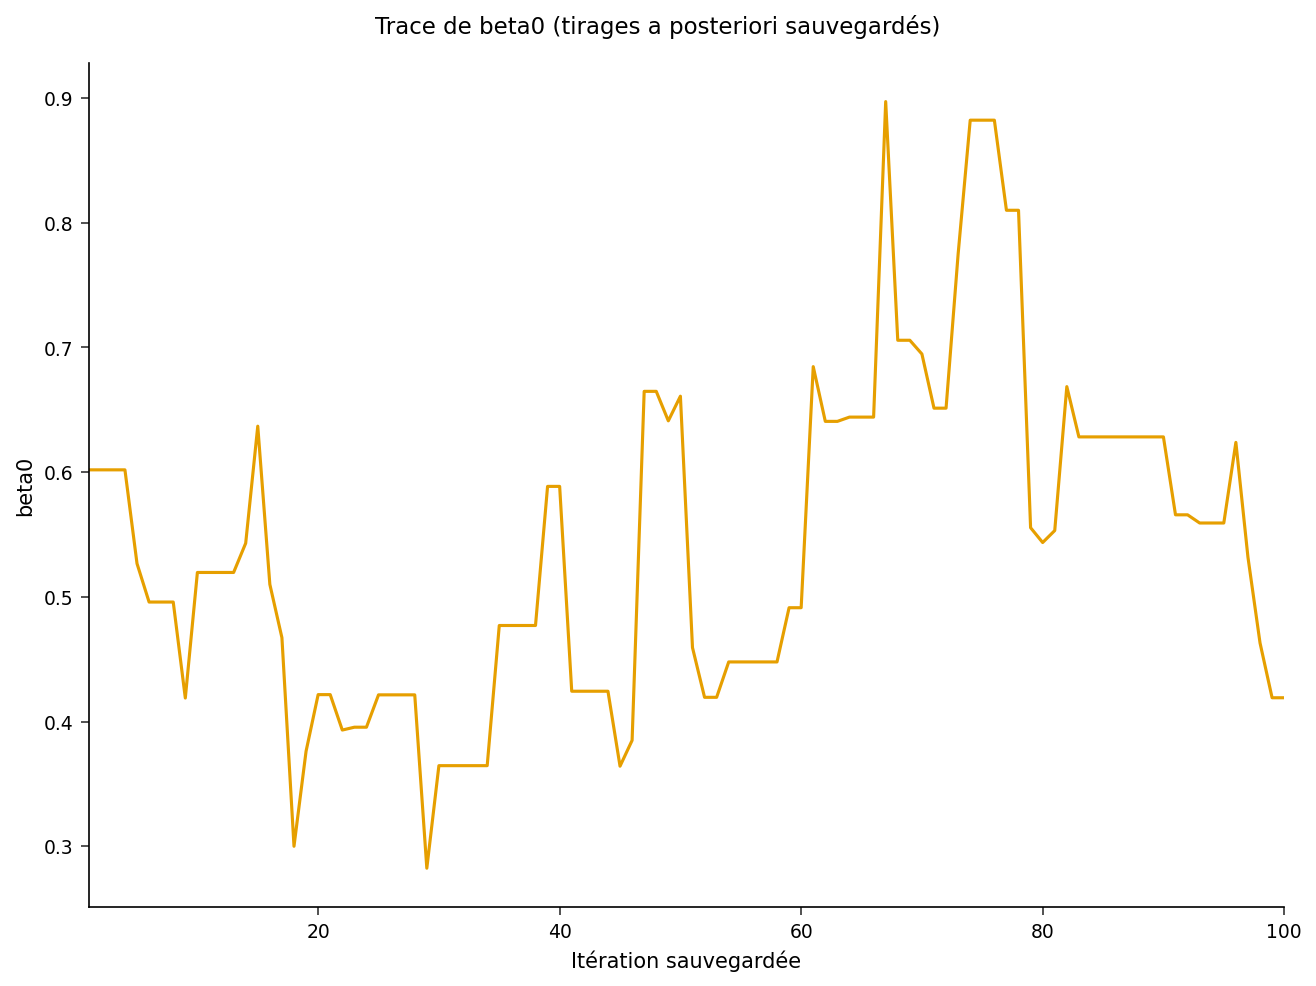

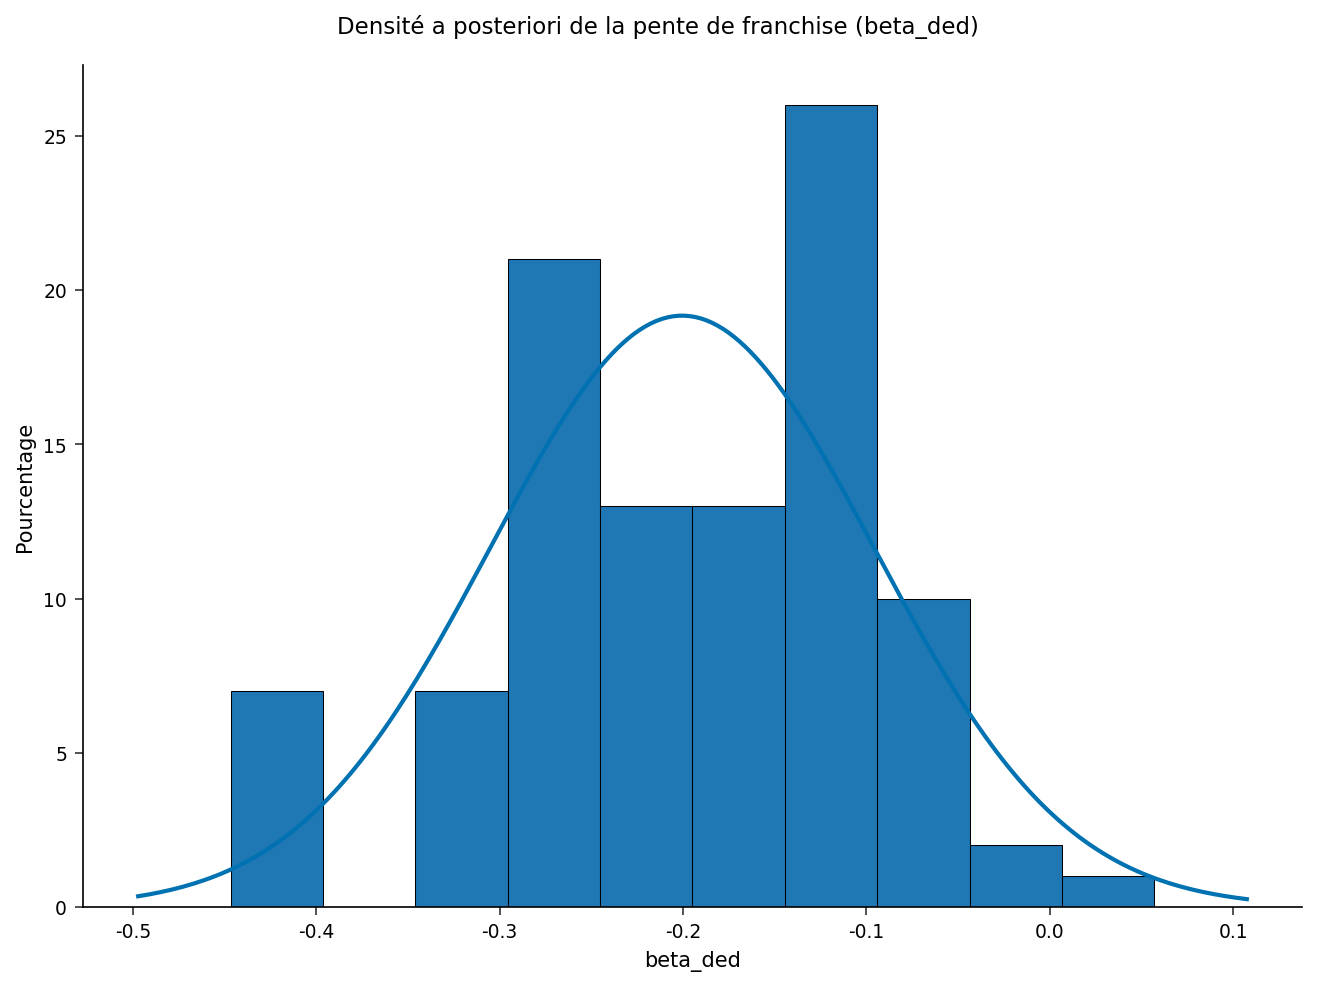

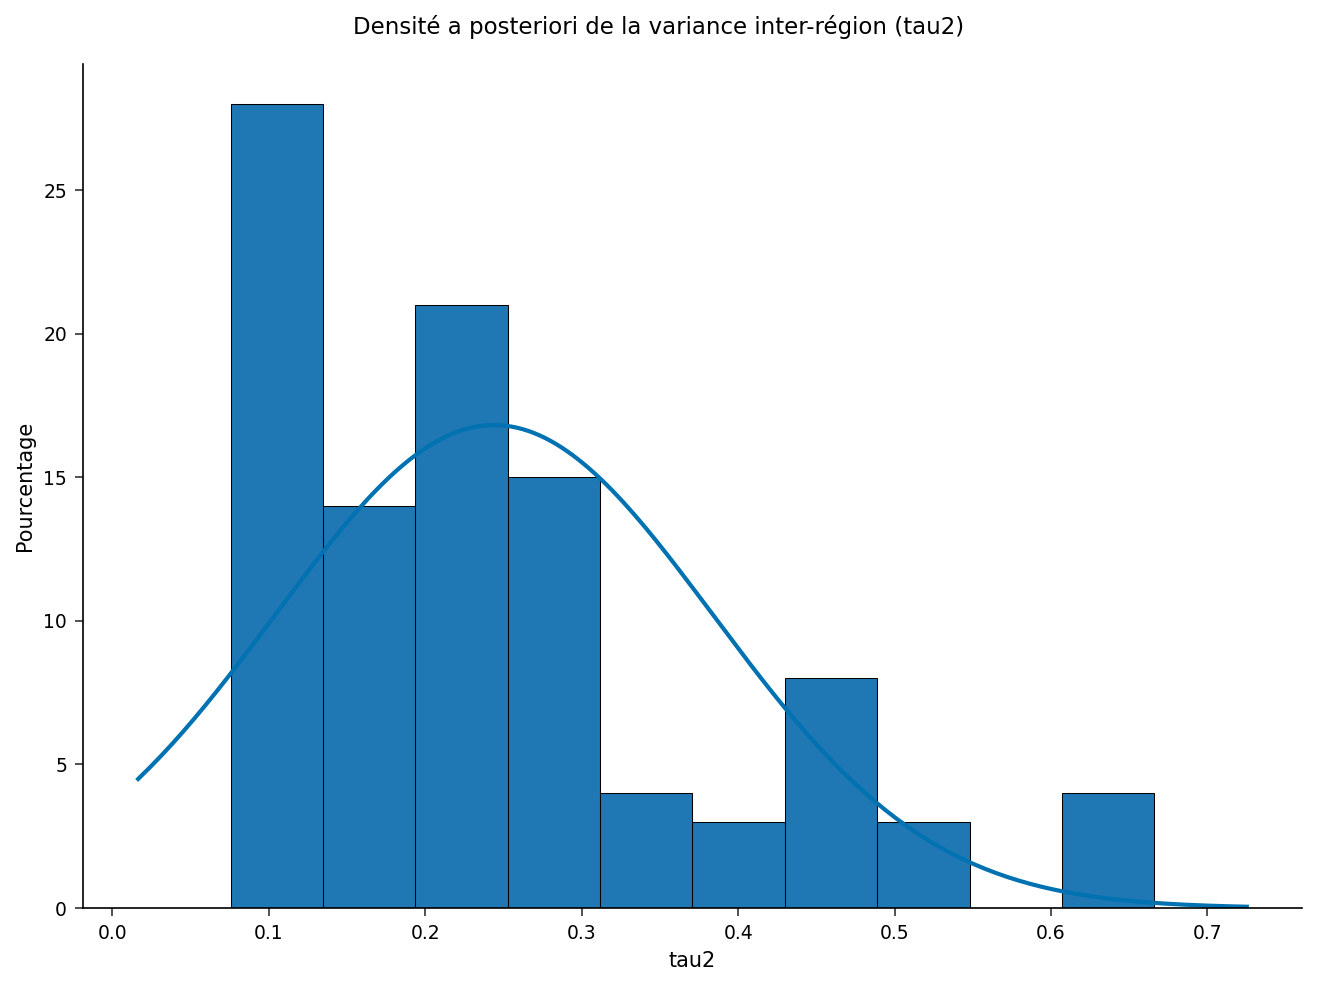

In [6]:
/* region_sd a été ajouté à post dans la vue de données de l'étape 5 */
données post2;
    définir post;
    region_sd = sqrt(tau2);
exécuter;

/* Trace de la fréquence-log de référence */
procédure sgplot données=post2;
    series x=iter y=beta0;
    titre "Trace de beta0 (tirages a posteriori sauvegardés)";
    xaxis étiquette="Itération sauvegardée";
    yaxis étiquette="beta0";
exécuter;

/* Densité a posteriori de la pente de franchise */
procédure sgplot données=post2;
    histogram beta_ded;
    density   beta_ded;
    titre "Densité a posteriori de la pente de franchise (beta_ded)";
    xaxis étiquette="beta_ded";
    yaxis étiquette="Pourcentage";
exécuter;

/* Densité a posteriori de la variance inter-région */
procédure sgplot données=post2;
    histogram tau2;
    density   tau2;
    titre "Densité a posteriori de la variance inter-région (tau2)";
    xaxis étiquette="tau2";
    yaxis étiquette="Pourcentage";
exécuter;

## Interprétation des résultats

**Ce que le modèle a produit :**

- **Structure retrouvée.** Les effets régionaux a posteriori (`post_mean_u`) suivent la vérité simulée (`true_eff`) en signe et en ordre : la région 5 (vérité +0,40) est la plus haute à +0,36, la région 4 (vérité -0,30) est la plus basse à -0,70, et la région 1 (vérité +0,05) se situe près du centre à +0,20. La pente de franchise `beta_ded` s'établit à -0,13 (négative, comme le processus générateur des données le spécifiait, bien que ramenée vers zéro par le petit échantillon de 96 polices) et `beta0` retrouve une fréquence-log de référence de 0,43 — preuve que la vraisemblance de Poisson hiérarchique et le décalage d'exposition ont été correctement spécifiés.
- **Regroupement partiel en action.** Comparons la `relativity` réduite de l'étape 4 aux fréquences brutes de l'étape 2. La fréquence brute de 3,41 de la région 5 est ramenée à une relativité de 1,43, et la fréquence brute de 0,45 de la région 4 remonte à une relativité de 0,49 — les régions fines sont contenues vers le centre du portefeuille et portent les **intervalles de crédibilité les plus larges**, exactement le comportement qu'un actuaire recherche : ne pas surtarifer ni sous-tarifer un territoire sur la base de quelques sinistres aléatoires.
- **Incertitude quantifiée.** La distribution a posteriori de `tau2` (moyenne d'environ 0,52) implique un écart-type inter-région `sqrt(tau2)` d'environ 0,72, qui mesure l'ampleur de l'hétérogénéité inter-région véritable subsistant après prise en compte du mix de franchises et de l'exposition — un intrant direct pour la confiance dans les relativités de territoire et pour l'incertitude de capital/réserve.
- **Diagnostics et ajustement du modèle.** Le **DIC rapporté est de 246,7**, un repère pour comparer cette spécification hiérarchique à des alternatives plus simples, entièrement regroupées ou entièrement non regroupées. Les tailles d'échantillon effectives sont modestes (`beta_ded` près de 525, les effets aléatoires et `beta0` de l'ordre de quelques dizaines), et le **diagnostic de Geweke signale les trois paramètres surveillés** — le graphique de trace montre `beta0` dérivant vers le haut sur les 100 premiers tirages sauvegardés. Avec seulement 96 années-police et des chaînes courtes en mode sans licence, cette non-convergence est attendue ; une exécution en production allongerait le rodage et l'échantillonnage, et pourrait reparamétrer, avant de se fier aux intervalles.

**Pourquoi le bayésien ici :** Les relativités de fréquence alimentent directement la tarification, et les régulateurs attendent de plus en plus une quantification de l'incertitude. PROC MCMC produit la *distribution a posteriori entière* pour chaque région, si bien que l'assureur peut affirmer, par exemple, « la relativité de fréquence de la région 4 a un intervalle de crédibilité à 95% autour de sa moyenne a posteriori de 0,49 » — une affirmation que les estimations ponctuelles classiques ne peuvent pas faire, et qui est la plus précieuse précisément pour les petits territoires à données limitées.